#INTERNSHIP PROJECT

---



# Multi-Series Forecasting for Retail Demand Optimization
The problem focuses on forecasting daily demand across multiple related time series defined by store-item combinations. It requires capturing both series-specific dynamics and shared temporal structures, handling seasonality and autocorrelation, and ensuring scalability across a large number of series. The objective is to generate reliable multi-horizon forecasts that can be used for data-driven inventory and supply chain decision-making.

**Retail Demand Forecasting Process**
 1. Import Libraries
 2. Load Dataset
 3. Exploratory Data Analysis (EDA)
 4. Data Cleaning
 5. Feature Engineering
 6. Train-Validation Split
 7. Model Building
 8. Model Evaluation
 9. Predict Test Data
 10. Create Submission File
 11. Feature Importance
 12. Conclusions

In [7]:
# STEP 1: Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Machine Learning
from sklearn.metrics import mean_absolute_error

# LightGBM
import lightgbm as lgb

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [8]:
#uploading daatset

from google.colab import files

uploaded = files.upload()

Saving sample_submission.csv to sample_submission.csv
Saving test.csv to test.csv
Saving train.csv to train.csv


In [9]:
# Load datasets

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
submission = pd.read_csv("sample_submission.csv")

print("Training Data Shape :", train.shape)
print("Testing Data Shape  :", test.shape)
print("Submission Shape    :", submission.shape)

Training Data Shape : (913000, 4)
Testing Data Shape  : (45000, 4)
Submission Shape    : (45000, 2)


In [10]:
train.head()
test.head()
submission.head()

,id,sales
0,0,52
1,1,52
2,2,52
3,3,52
4,4,52


In [11]:
#Initial Data Inspection
train.head()
train.info()
train.describe()
train.isnull().sum()
train.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


np.int64(0)

### EDA (Exploratory Data Analysis)

In [12]:
# Convert date column to datetime format
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

print("Train Date Type :", train['date'].dtype)
print("Test Date Type  :", test['date'].dtype)

Train Date Type : datetime64[ns]
Test Date Type  : datetime64[ns]


In [13]:
# Creating the date features
# Extract date-related features

train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day
train['dayofweek'] = train['date'].dt.dayofweek
train['weekofyear'] = train['date'].dt.isocalendar().week.astype(int)
train['quarter'] = train['date'].dt.quarter

# Apply same transformations to test dataset

test['year'] = test['date'].dt.year
test['month'] = test['date'].dt.month
test['day'] = test['date'].dt.day
test['dayofweek'] = test['date'].dt.dayofweek
test['weekofyear'] = test['date'].dt.isocalendar().week.astype(int)
test['quarter'] = test['date'].dt.quarter

train.head()

,date,store,item,sales,year,month,day,dayofweek,weekofyear,quarter
0,2013-01-01,1,1,13,2013,1,1,1,1,1
1,2013-01-02,1,1,11,2013,1,2,2,1,1
2,2013-01-03,1,1,14,2013,1,3,3,1,1
3,2013-01-04,1,1,13,2013,1,4,4,1,1
4,2013-01-05,1,1,10,2013,1,5,5,1,1


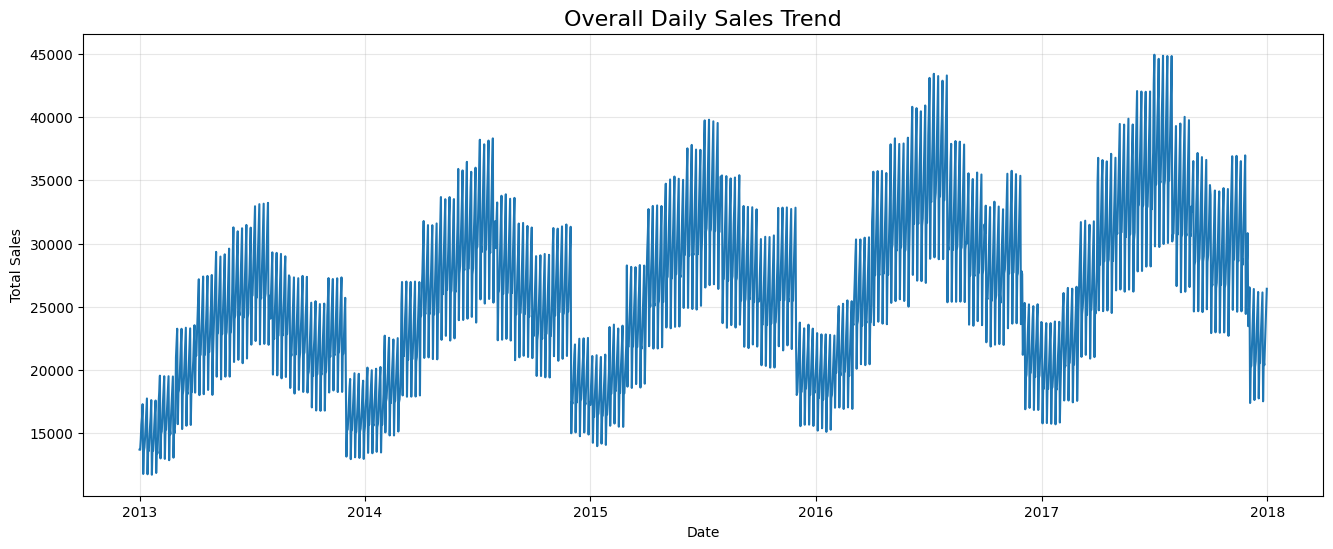

In [14]:
# Overall Daily Sales Trend : to know how the sales behave over time.

# Aggregate sales by date
daily_sales = train.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(16,6))

plt.plot(daily_sales['date'],
         daily_sales['sales'],
         linewidth=1.5)

plt.title("Overall Daily Sales Trend", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.grid(alpha=0.3)

plt.show()

Obs: this graph displays the total sales across all stores and items for every single day over the five-year period. Instead of looking at 500 individual time series, we're looking at the combined sales to understand the overall business trend.

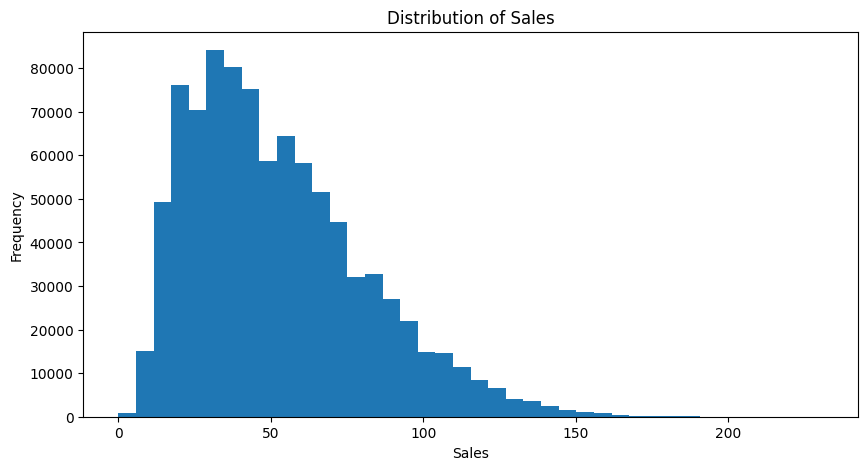

In [15]:
# Sales Distribution

plt.figure(figsize=(10,5))

plt.hist(train['sales'],
         bins=40)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

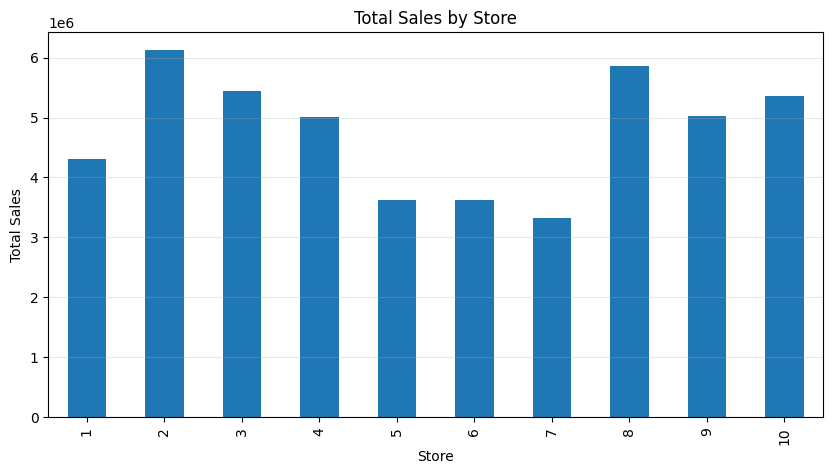

In [16]:
# Sales by Store : to know which stores generate the highest sales.

store_sales = train.groupby('store')['sales'].sum()

plt.figure(figsize=(10,5))

store_sales.plot(kind='bar')

plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")

plt.grid(axis='y', alpha=0.3)

plt.show()

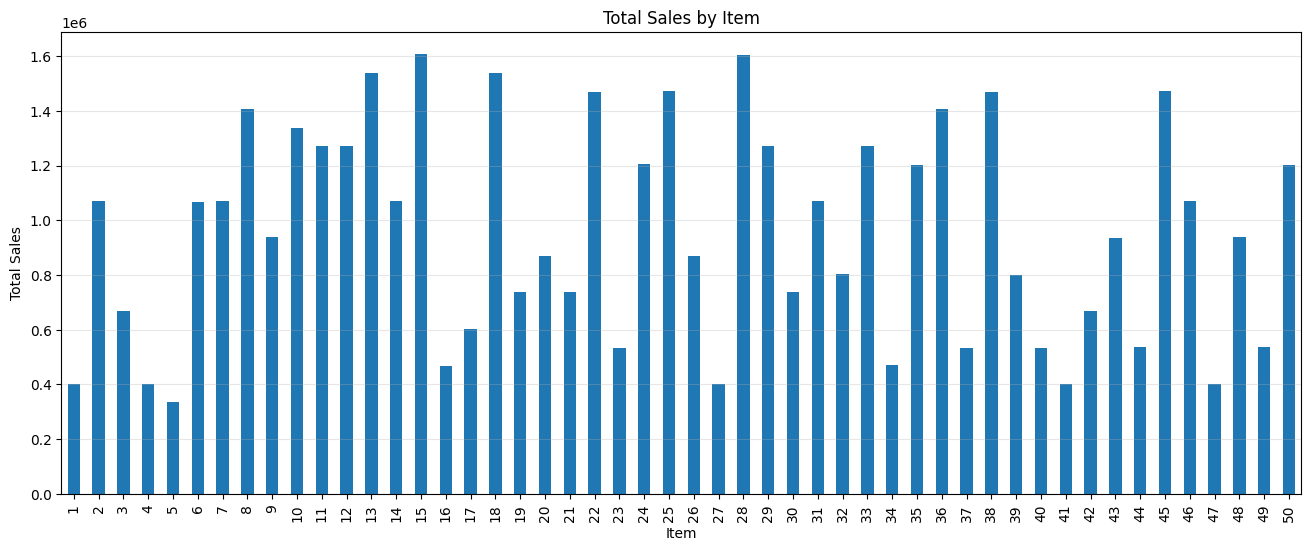

In [17]:
# Sales by Item: To compare the popularity of different items

item_sales = train.groupby('item')['sales'].sum()

plt.figure(figsize=(16,6))

item_sales.plot(kind='bar')

plt.title("Total Sales by Item")
plt.xlabel("Item")
plt.ylabel("Total Sales")

plt.grid(axis='y', alpha=0.3)

plt.show()

##Time-Series EDA

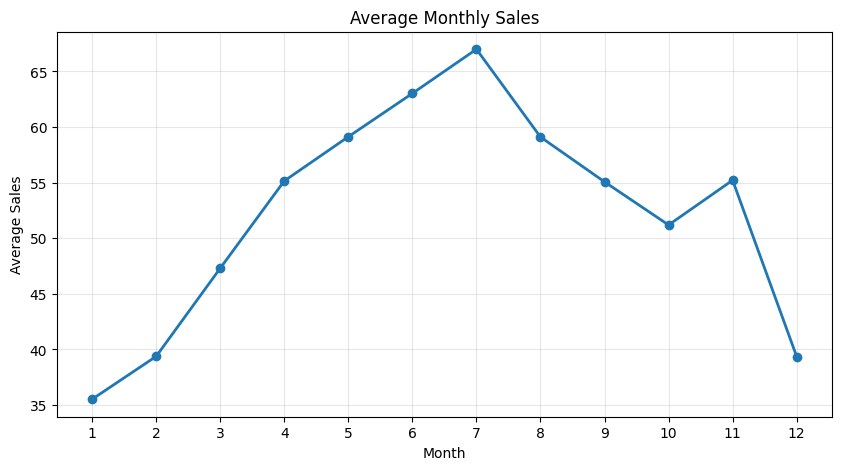

In [18]:
# Monthly Sales Trend: To see if certain months consistently have higher or lower sales. If the answer is yes, then month is an important feature for forecasting.

monthly_sales = train.groupby('month')['sales'].mean()

plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o',
         linewidth=2)

plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.xticks(range(1,13))
plt.grid(alpha=0.3)

plt.show()

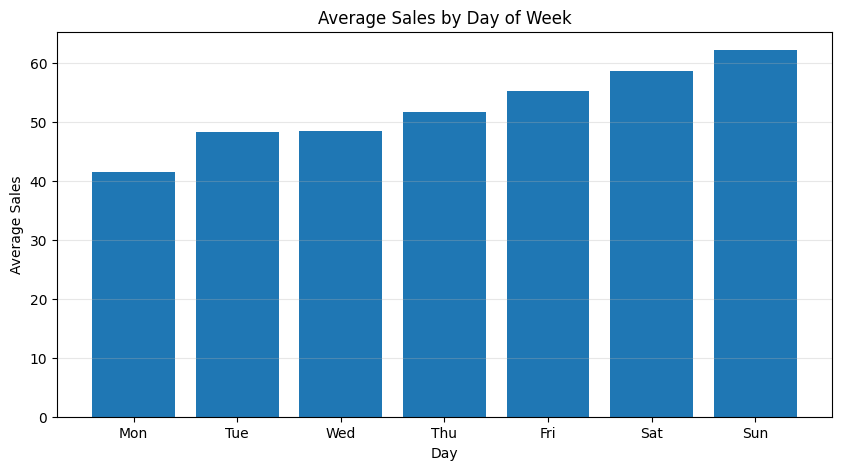

In [19]:
# Sales by Day of Week: One of the strongest patterns in retail is weekday vs weekend demand.

# Average Sales by Day of Week
weekday_sales = train.groupby('dayofweek')['sales'].mean()

days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

plt.figure(figsize=(10,5))

plt.bar(days,
        weekday_sales.values)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Sales")

plt.grid(axis='y', alpha=0.3)

plt.show()

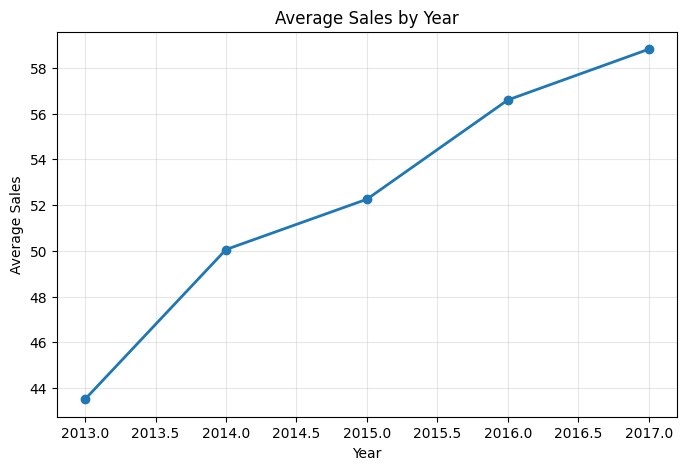

In [20]:
# Avg Year-wise Sales Trend

yearly_sales = train.groupby('year')['sales'].mean()

plt.figure(figsize=(8,5))

plt.plot(yearly_sales.index,
         yearly_sales.values,
         marker='o',
         linewidth=2)

plt.title("Average Sales by Year")
plt.xlabel("Year")
plt.ylabel("Average Sales")

plt.grid(alpha=0.3)

plt.show()

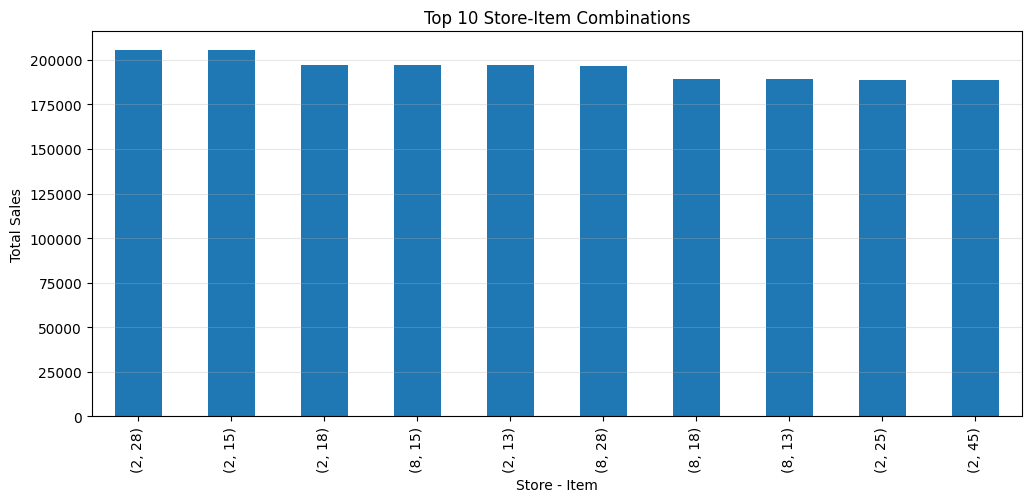

In [21]:
# Top 10 Store-Item Combinations: Since forecasting problem is based on store-item combinations, not just stores or items separately.

# Top Store-Item Combinations
store_item_sales = (
    train.groupby(['store','item'])['sales']
         .sum()
         .sort_values(ascending=False)
         .head(10)
)

plt.figure(figsize=(12,5))

store_item_sales.plot(kind='bar')

plt.title("Top 10 Store-Item Combinations")
plt.xlabel("Store - Item")
plt.ylabel("Total Sales")

plt.grid(axis='y', alpha=0.3)

plt.show()

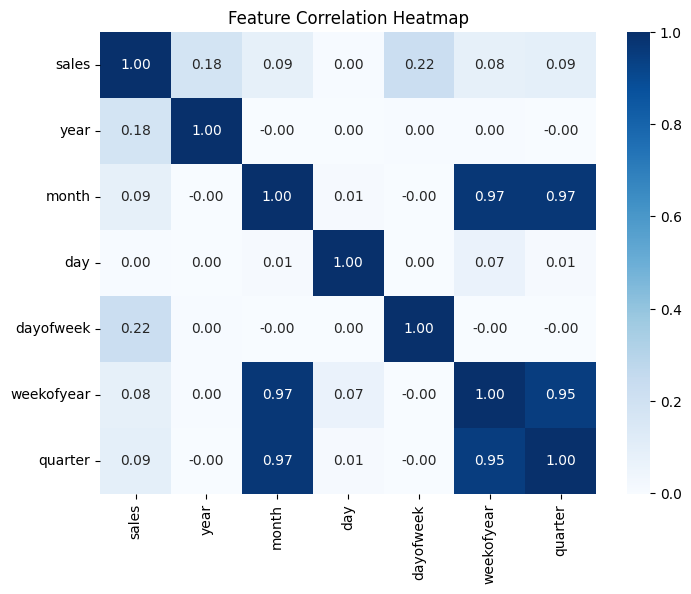

In [22]:
#Correlation Heatmap : relationships between our numerical features.
# Here we use only engineered numeric features, since correlation isn't meaningful for raw categorical IDs like store and item.

import seaborn as sns

corr = train[['sales',
              'year',
              'month',
              'day',
              'dayofweek',
              'weekofyear',
              'quarter']].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap='Blues',
            fmt=".2f")

plt.title("Feature Correlation Heatmap")

plt.show()

##Feature Engineering

In [23]:
# Sort Data : Since time series data must be in chronological order before creating the lag features

train = train.sort_values(by=['store', 'item', 'date']).reset_index(drop=True)

train.head()

,date,store,item,sales,year,month,day,dayofweek,weekofyear,quarter
0,2013-01-01,1,1,13,2013,1,1,1,1,1
1,2013-01-02,1,1,11,2013,1,2,2,1,1
2,2013-01-03,1,1,14,2013,1,3,3,1,1
3,2013-01-04,1,1,13,2013,1,4,4,1,1
4,2013-01-05,1,1,10,2013,1,5,5,1,1


In [24]:
# Lag Features

lags = [1, 7, 30] #since 1, 7 and 30th are the most commen days to check the pervious sales

for lag in lags:
    train[f'lag_{lag}'] = (
        train.groupby(['store', 'item'])['sales']
             .shift(lag)
    )

train.head(15)

,date,store,item,sales,year,month,day,dayofweek,weekofyear,quarter,lag_1,lag_7,lag_30
0,2013-01-01,1,1,13,2013,1,1,1,1,1,NaN,NaN,NaN
1,2013-01-02,1,1,11,2013,1,2,2,1,1,13.0,NaN,NaN
2,2013-01-03,1,1,14,2013,1,3,3,1,1,11.0,NaN,NaN
3,2013-01-04,1,1,13,2013,1,4,4,1,1,14.0,NaN,NaN
4,2013-01-05,1,1,10,2013,1,5,5,1,1,13.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10,2013-01-11,1,1,9,2013,1,11,4,2,1,9.0,13.0,NaN
11,2013-01-12,1,1,7,2013,1,12,5,2,1,9.0,10.0,NaN
12,2013-01-13,1,1,10,2013,1,13,6,2,1,7.0,12.0,NaN
13,2013-01-14,1,1,12,2013,1,14,0,3,1,10.0,10.0,NaN


In [25]:
# Rolling Mean Features : Instead of looking at only yesterday, model sees the average demand over recent days.

windows = [7, 30]

for window in windows:
    train[f'rolling_mean_{window}'] = (
        train.groupby(['store', 'item'])['sales']
             .transform(lambda x: x.shift(1).rolling(window).mean()) #here shift(1) used to avoid the data leakage
    )

train.head()

,date,store,item,sales,year,month,day,dayofweek,weekofyear,quarter,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
0,2013-01-01,1,1,13,2013,1,1,1,1,1,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,1,1,11,2013,1,2,2,1,1,13.0,NaN,NaN,NaN,NaN
2,2013-01-03,1,1,14,2013,1,3,3,1,1,11.0,NaN,NaN,NaN,NaN
3,2013-01-04,1,1,13,2013,1,4,4,1,1,14.0,NaN,NaN,NaN,NaN
4,2013-01-05,1,1,10,2013,1,5,5,1,1,13.0,NaN,NaN,NaN,NaN


In [26]:
# Rolling Standard Deviation : tells how stable demand is.

for window in windows:
    train[f'rolling_std_{window}'] = (
        train.groupby(['store', 'item'])['sales']
             .transform(lambda x: x.shift(1).rolling(window).std())
    )

In [27]:
# Expanding Mean : tells the average demand since the beginning.

train['expanding_mean'] = (
    train.groupby(['store', 'item'])['sales']
         .transform(lambda x: x.shift(1).expanding().mean())
)

In [28]:
#checking missing values after lag and rolling

train.isnull().sum().sort_values(ascending=False)

,0
rolling_std_30,15000
rolling_mean_30,15000
lag_30,15000
rolling_std_7,3500
rolling_mean_7,3500
...,...
day,0
month,0
year,0
sales,0


In [29]:
#removing missing rows
train = train.dropna().reset_index(drop=True)

print(train.shape)

(898000, 18)


In [30]:
#verifying new features
train.head()

,date,store,item,sales,year,month,day,dayofweek,weekofyear,quarter,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,expanding_mean
0,2013-01-31,1,1,13,2013,1,31,3,5,1,9.0,8.0,13.0,10.285714,10.500000,2.751623,3.104502,10.500000
1,2013-02-01,1,1,11,2013,2,1,4,5,1,13.0,14.0,11.0,11.000000,10.500000,2.708013,3.104502,10.580645
2,2013-02-02,1,1,21,2013,2,2,5,5,1,11.0,12.0,14.0,10.571429,10.500000,2.370453,3.104502,10.593750
3,2013-02-03,1,1,15,2013,2,3,6,5,1,21.0,12.0,13.0,11.857143,10.733333,4.634241,3.600128,10.909091
4,2013-02-04,1,1,14,2013,2,4,0,6,1,15.0,11.0,10.0,12.285714,10.800000,4.785892,3.661543,11.029412


Obs : these features provide the model with both short-term memory (recent sales) and long-term context (historical averages).

##Model Building

In [31]:
# Train-Validation Split (Time-Based)

train_data = train[train['date'] < '2017-01-01']
valid_data = train[train['date'] >= '2017-01-01']

print("Training Set Shape   :", train_data.shape)
print("Validation Set Shape :", valid_data.shape)

Training Set Shape   : (715500, 18)
Validation Set Shape : (182500, 18)


Obs : here we are not using 'train_test_split' because that randomly shuffles the data and causes information from the future to leak into the training set.

In [32]:
# Feature Selection : We exclude: date (LightGBM cannot use datetime directly) and sales (our target)

FEATURES = [
    'store',
    'item',
    'year',
    'month',
    'day',
    'dayofweek',
    'weekofyear',
    'quarter',
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_mean_30',
    'rolling_std_7',
    'rolling_std_30',
    'expanding_mean'
]

TARGET = 'sales'

In [33]:
#Create Training and Validation Sets

X_train = train_data[FEATURES]
y_train = train_data[TARGET]

X_valid = valid_data[FEATURES]
y_valid = valid_data[TARGET]

print("Training Features :", X_train.shape)
print("Validation Features :", X_valid.shape)

Training Features : (715500, 16)
Validation Features : (182500, 16)


In [34]:
# Building a Baseline Model

# Baseline Prediction : A common baseline in forecasting is to predict that today's sales will be the same as yesterday's sales.
baseline_pred = X_valid['lag_1']

In [35]:
#Evaluate the Baseline : This gives us a benchmark that our LightGBM model should beat.

from sklearn.metrics import mean_absolute_error
baseline_mae = mean_absolute_error(y_valid, baseline_pred)

print("Baseline MAE :", round(baseline_mae, 2))

Baseline MAE : 11.24


In [36]:
#Implementing SMAPE (used in the question)

import numpy as np

def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0
    return np.mean(diff) * 100

#evaluating the baseline:
baseline_smape = smape(
    y_valid.values,
    baseline_pred.values
)

print("Baseline SMAPE :", round(baseline_smape, 2))

Baseline SMAPE : 21.12


In [37]:
# Train LightGBM Model

model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric='l1'
)

print("LightGBM Model Trained Successfully!")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040080 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2006
[LightGBM] [Info] Number of data points in the train set: 715500, number of used features: 16
[LightGBM] [Info] Start training from score 51.056034
LightGBM Model Trained Successfully!


####NOTE : Here we are using LightGBM because it is one of the best algorithms for structured/tabular data like this because it:
####Handles nonlinear relationships; Works well with engineered features; Trains quickly; Is widely used in forecasting competitions and industry.


In [38]:
# Predict on Validation Set

valid_pred = model.predict(X_valid)
print(valid_pred[:10])

[19.28719911 12.32788243 14.52122191 14.590805   15.4798829  16.42513311
 17.67009532 18.61058184 12.32184213 14.69613315]


In [39]:
# Evaluating LightGBM

# MAE
lightgbm_mae = mean_absolute_error(
    y_valid,
    valid_pred
)

print("LightGBM MAE :", round(lightgbm_mae,2))

# SMAPE
lightgbm_smape = smape(
    y_valid.values,
    valid_pred
)

print("LightGBM SMAPE :", round(lightgbm_smape,2))

LightGBM MAE : 6.01
LightGBM SMAPE : 11.9


In [40]:
import pandas as pd

# Comparing Models

comparison = pd.DataFrame({
    "Model":[
        "Baseline",
        "LightGBM"
    ],
    "MAE":[
        baseline_mae,
        lightgbm_mae
    ],
    "SMAPE":[
        baseline_smape,
        lightgbm_smape
    ]
})

comparison

,Model,MAE,SMAPE
0,Baseline,11.244734,21.124126
1,LightGBM,6.010517,11.903676


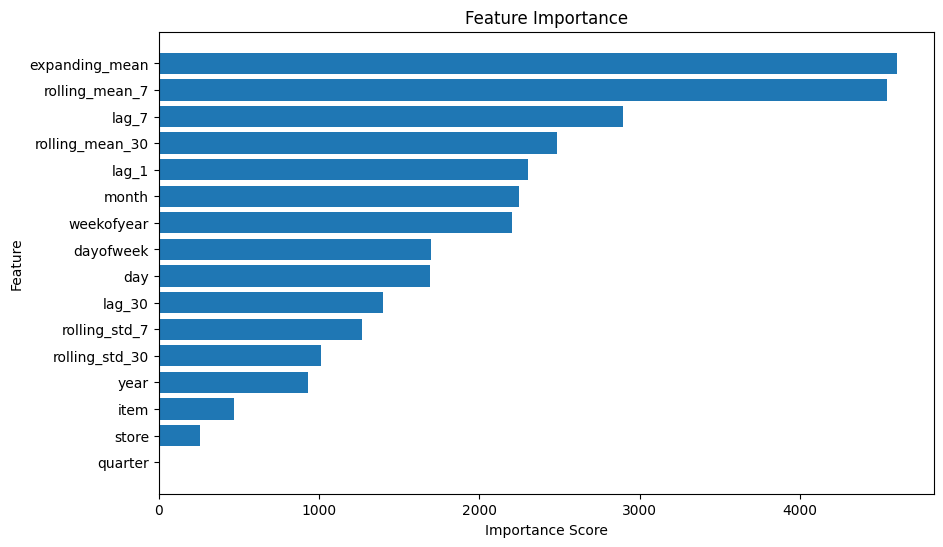

In [41]:
#Feature Importance

importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

OBS:
 Expanding Mean: model relied heavily on the historical average sales of each store-item combination.
 - Rolling Mean: captures the recent weekly demand trend.
 - Lag 7: tells us What happened exactly one week ago.
 - Lag 1 : tells us about Yesterday's sales.
 - Month & Week of Year : these are capturing the affects of differnt seasons.
 - Store, Quarter & Item : Once the model already knowa historical sales,rolling averages and lags the store and item IDs add relatively less new information.

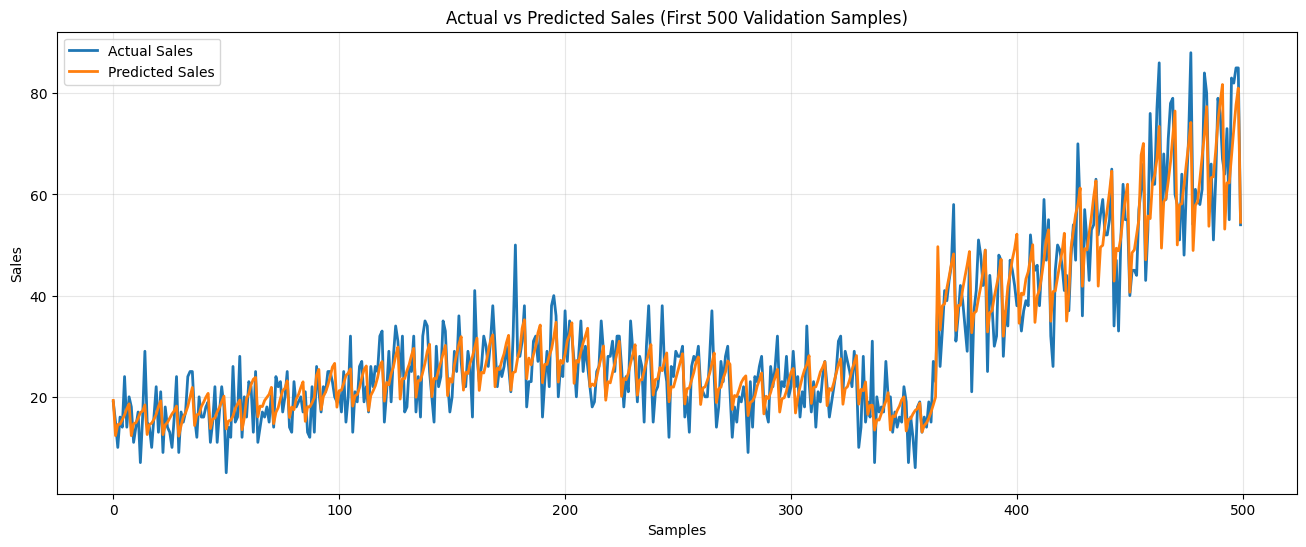

In [42]:
# Actual vs Predicted Plot

plt.figure(figsize=(16,6))

plt.plot(
    y_valid.values[:500],
    label='Actual Sales',
    linewidth=2
)

plt.plot(
    valid_pred[:500],
    label='Predicted Sales',
    linewidth=2
)

plt.title("Actual vs Predicted Sales (First 500 Validation Samples)")
plt.xlabel("Samples")
plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

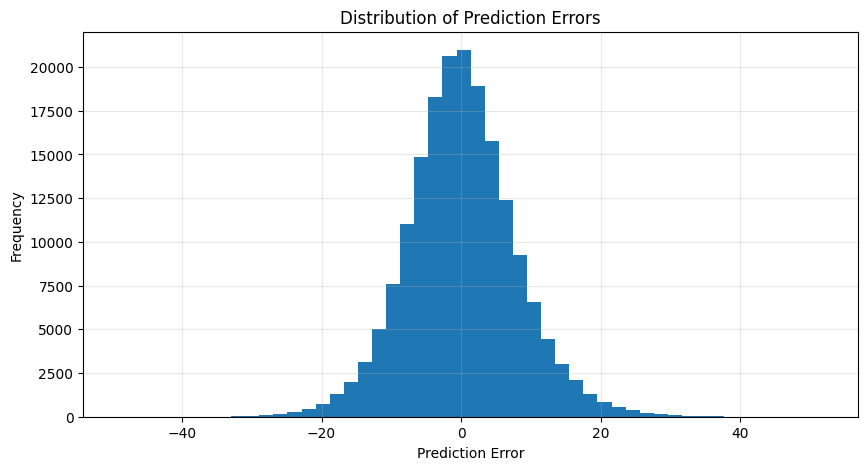

In [43]:
# Prediction Error Distribution : to see see how large the errors are.

# Residual Analysis
errors = y_valid - valid_pred

plt.figure(figsize=(10,5))

plt.hist(errors, bins=50)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

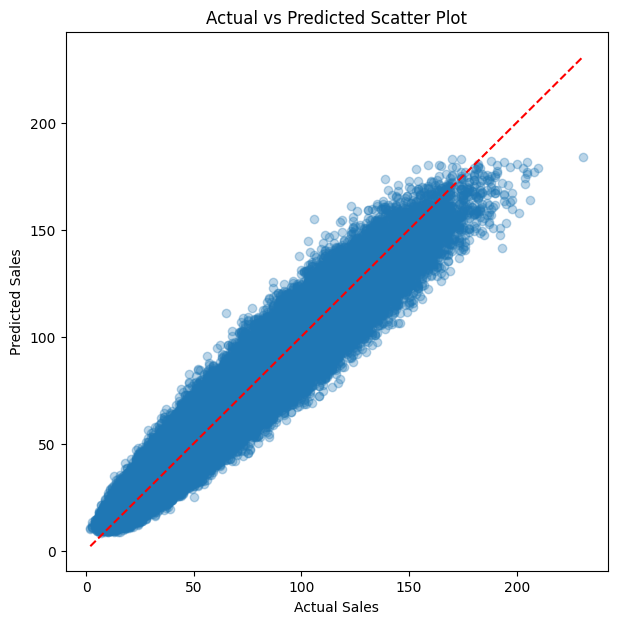

In [44]:
# Scatter Plot
plt.figure(figsize=(7,7))

plt.scatter(
    y_valid,
    valid_pred,
    alpha=0.3
)

plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()],
    'r--'
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Scatter Plot")

plt.show()

##CONCLUSION:
####This project successfully developed a multi-series retail demand forecasting model using historical sales data from multiple stores and items. After performing data preprocessing, exploratory data analysis, and feature engineering, a LightGBM model was trained and evaluated against a baseline forecasting approach. The proposed model achieved a substantial improvement in forecasting accuracy, reducing both MAE and SMAPE compared to the baseline. The results demonstrate that temporal and historical demand features play a significant role in improving retail demand forecasting. This project highlights the practical application of machine learning techniques for inventory planning and supply chain optimization.